<a href="https://colab.research.google.com/github/ernestoaguaysol-unpaz/sistemas-inteligentes-2026/blob/main/03_redes_convolucionales/004_CNN_clasificacion_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import requests
from PIL import Image
from io import BytesIO

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# Setear globalmente los estilos de matplotlib
sns.set()

# Cargar y explorar dataset CIFAR

In [2]:
# Algunas constantes que van a ser utilizadas en varios lugares del código.

# Nombre del modelo
modelo_nombre = "CIFAR10_modelo_1"

# Configs para el entrenamiento
epochs = 30
batch_size = 32
learning_rate = 0.001

# Nombres de las clases
class_names = ['avión', 'auto', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'bote', 'camión']

In [15]:
# Cargar y preparar los datos CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

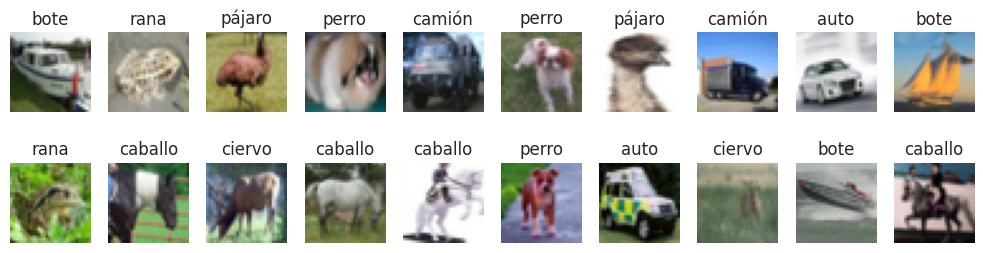

In [6]:
# Veamos algunos ejemplos

indices_al_azar = np.random.choice(X_train.shape[0], size=20, replace=False)

imagenes_imagen = X_train[indices_al_azar]
imagenes_etiquetas = y_train[indices_al_azar]

fig, axs = plt.subplots(2, 10, figsize=(10, 3))

for i in range(20):
    row, col = i // 10, i % 10
    axs[row, col].imshow(imagenes_imagen[i])
    axs[row, col].set_title(class_names[imagenes_etiquetas[i][0]])
    axs[row, col].axis("off")

plt.tight_layout()
plt.show()

# Preparar, entrenar y evaluar el modelo

In [32]:
# Aislar la primera imagen del lote
primera_imagen = X_train[0]
print("\nForma de una sola imagen aislada:", primera_imagen.shape)


Forma de una sola imagen aislada: (32, 32, 3)


In [33]:
# Inspeccionar los valores de los píxeles
print("\nMatriz de píxeles (RGB) de la primera imagen:")
print(primera_imagen)


Matriz de píxeles (RGB) de la primera imagen:
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [34]:
# Ver solo el canal Rojo (R) de esa primera imagen
print("\nSolo el canal ROJO de la primera imagen:")
print(primera_imagen[:, :, 0])


Solo el canal ROJO de la primera imagen:
[[ 59  43  50 ... 158 152 148]
 [ 16   0  18 ... 123 119 122]
 [ 25  16  49 ... 118 120 109]
 ...
 [208 201 198 ... 160  56  53]
 [180 173 186 ... 184  97  83]
 [177 168 179 ... 216 151 123]]


In [35]:
# Normalizar los píxeles a valores en el rango [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

In [37]:
# Aislar la primera imagen del lote
primera_imagen = X_train[0]
print("\nForma de una sola imagen aislada:", primera_imagen.shape)


Forma de una sola imagen aislada: (32, 32, 3)


In [38]:
# Inspeccionar los valores de los píxeles
print("\nMatriz de píxeles (RGB) de la primera imagen:")
print(primera_imagen)


Matriz de píxeles (RGB) de la primera imagen:
[[[0.23137255 0.24313725 0.24705882]
  [0.16862745 0.18039216 0.17647059]
  [0.19607843 0.18823529 0.16862745]
  ...
  [0.61960784 0.51764706 0.42352941]
  [0.59607843 0.49019608 0.4       ]
  [0.58039216 0.48627451 0.40392157]]

 [[0.0627451  0.07843137 0.07843137]
  [0.         0.         0.        ]
  [0.07058824 0.03137255 0.        ]
  ...
  [0.48235294 0.34509804 0.21568627]
  [0.46666667 0.3254902  0.19607843]
  [0.47843137 0.34117647 0.22352941]]

 [[0.09803922 0.09411765 0.08235294]
  [0.0627451  0.02745098 0.        ]
  [0.19215686 0.10588235 0.03137255]
  ...
  [0.4627451  0.32941176 0.19607843]
  [0.47058824 0.32941176 0.19607843]
  [0.42745098 0.28627451 0.16470588]]

 ...

 [[0.81568627 0.66666667 0.37647059]
  [0.78823529 0.6        0.13333333]
  [0.77647059 0.63137255 0.10196078]
  ...
  [0.62745098 0.52156863 0.2745098 ]
  [0.21960784 0.12156863 0.02745098]
  [0.20784314 0.13333333 0.07843137]]

 [[0.70588235 0.54509804 0.

In [41]:
# Convertir etiquetas a formato one-hot
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [42]:
type(X_train.shape)
X_train.shape[1:]

(32, 32, 3)

In [43]:
# Modelo
modelo = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    #Dropout(0.2),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    #Dropout(0.2),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    #Dropout(0.2),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    #Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [44]:
# Compilar el modelo
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

In [47]:
modelo.summary(line_length=80)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                   │ (None, 32, 32, 16)       │           448 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 32, 32, 16)       │         2,320 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 16, 16, 16)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 16, 16, 32)       │         4,640 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 16, 16, 32)       │         9,248 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 8, 8, 32)         │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)                 │ (None, 8, 8, 64)         │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)                 │ (None, 8, 8, 64)         │        36,928 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 4, 4, 64)         │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)                 │ (None, 4, 4, 128)        │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)                 │ (None, 2, 2, 128)        │       147,584 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)    │ (None, 1, 1, 128)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten (Flatten)                 │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 128)              │        16,512 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 10)               │         1,290 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 311,322 (1.19 MB)

 Trainable params: 311,322 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Entrenar el modelo
history = modelo.fit(X_train,
                     y_train,
                     epochs=epochs,
                     batch_size=batch_size,
                     # validation_data=(X_train, y_train)
                     )

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.3796 - loss: 1.6691
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5738 - loss: 1.1787
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6476 - loss: 0.9877
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6943 - loss: 0.8663
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7258 - loss: 0.7739
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7544 - loss: 0.6952
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7763 - loss: 0.6345
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7966 - loss: 0.5741
Epoch 9/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8158 - loss: 0.5214
Epoch 10/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8286 - loss: 0.4821
Epoch 11/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8449 - loss: 0.4367
Epoch 12/30
1563/1563 ━━━━━━

In [49]:
# Evaluar el modelo con datos de entrenamiento y de prueba

train_loss, train_acc = modelo.evaluate(X_train, y_train)

test_loss, test_acc = modelo.evaluate(X_test, y_test)

train_loss = round(train_loss, 3)
train_acc = round(train_acc, 3)
test_loss = round(test_loss, 3)
test_acc = round(test_acc, 3)

print(f'Train accuracy: {train_acc}')
print(f'Test accuracy: {test_acc}')

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9414 - loss: 0.1711
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7154 - loss: 1.3770
Train accuracy: 0.941
Test accuracy: 0.715


In [50]:
# Predicciones con el conjunto de prueba.
y_pred_test = modelo.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [51]:
# Clases de las predicciones.
y_pred_test_clase = np.argmax(y_pred_test, axis=1)

# Clases del conjunto de prueba.
y_test_clase = np.argmax(y_test, axis=1)

# Exactitud, Matriz de confusión, Predicciones

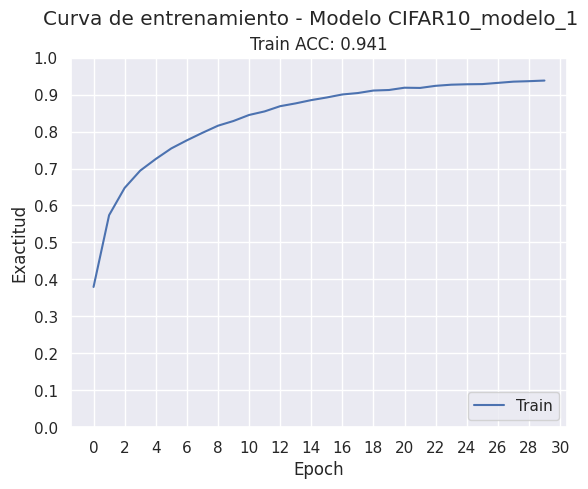

In [52]:
# Curva de entrenamiento

fig, ax = plt.subplots()

fig.suptitle(f"Curva de entrenamiento - Modelo {modelo_nombre}")

ax.plot(history.history['accuracy'], label='Train')

ax.set_title(f"Train ACC: {train_acc}")
ax.set_xticks(np.arange(0, epochs + 1, 2))
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xlabel('Epoch')
ax.set_ylabel('Exactitud')

ax.legend(loc='lower right')
ax.grid(True)

plt.show()

In [53]:
def plot_matriz_confusion(matriz_de_confusion,
                          labels = False,
                          titulo = "Matriz de confusión",
                          subtitulo = ""):
    fig, ax = plt.subplots()

    ax = sns.heatmap(matriz_de_confusion,
                     annot=True,
                     cbar=False,
                     fmt ='g')

    if(labels != False):
        ax.set_xticklabels(labels, rotation=45)
        ax.set_yticklabels(labels, rotation=0)

    fig.suptitle(titulo)
    ax.set_title(subtitulo)

    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta real")

    plt.tight_layout()

    plt.show()

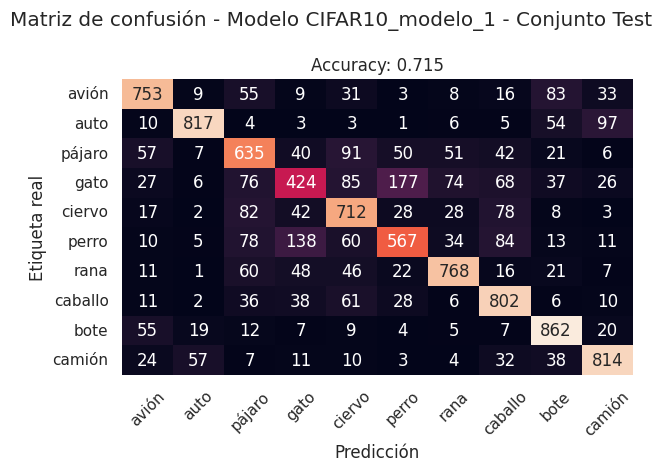

In [54]:
plot_matriz_confusion(confusion_matrix(y_test_clase, y_pred_test_clase),
                      labels=class_names,
                      titulo=f"Matriz de confusión - Modelo {modelo_nombre} - Conjunto Test",
                      subtitulo=f"Accuracy: {test_acc}")

In [55]:
def preprocess_image(image):
    image = image.resize((32, 32))  # Redimensionar la imagen para ajustarla al tamaño de entrada CIFAR-10
    image = np.array(image)  # Convertir imagen PIL en matriz numpy
    image = image / 255.0  # Normalizar los valores de los píxeles
    return image

In [56]:
image_urls = [
    'https://img.freepik.com/foto-gratis/tiro-vertical-enfoque-superficial-caballo-marron-que-lleva-arnes-caminando-sobre-suelo-arenoso_181624-22278.jpg',
    'https://img.freepik.com/foto-gratis/disparo-vertical-enfoque-superficial-lindo-cachorro-golden-retriever-sentado-suelo-hierba_181624-27259.jpg',
    'https://img.freepik.com/foto-gratis/gato-rojo-o-blanco-i-estudio-blanco_155003-13189.jpg',
    'https://img.freepik.com/foto-gratis/vista-barco-flotando-agua-paisajes-naturales_23-2150693362.jpg'
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step


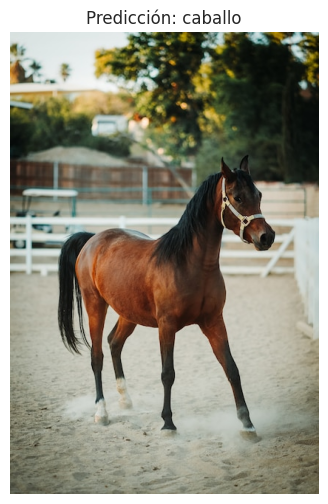

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


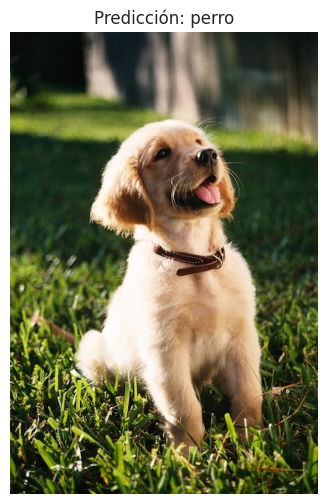

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


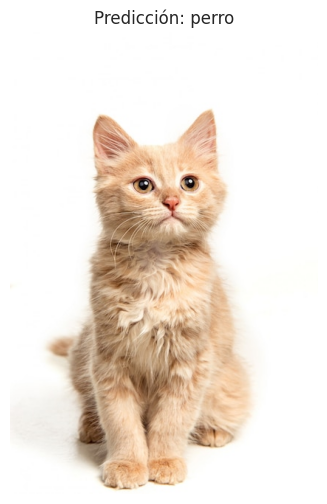

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


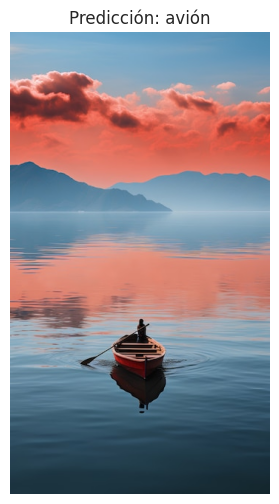

In [57]:
for url in image_urls:
    try:
        # Descargar la imagen desde la URL
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Esto levantará una excepción si hay un error en la descarga

        # Cargar la imagen con PIL
        original_image = Image.open(BytesIO(response.content))

        # Guardar una copia de la imagen original para mostrarla
        display_image = original_image.copy()

        # Preprocesar la imagen para el modelo
        processed_image = preprocess_image(original_image)

        # Hacer la predicción
        # Asegurate de que la imagen tenga la forma correcta para tu modelo
        input_image = np.expand_dims(processed_image, axis=0)
        predictions = modelo.predict(input_image)
        predicted_class = np.argmax(predictions)

        # Mostrar la imagen original
        plt.figure(figsize=(6, 6))
        plt.imshow(display_image)
        plt.title(f'Predicción: {class_names[predicted_class]}')
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error procesando la imagen {url}: {e}")